In [14]:
import numpy as np
from optional import Korezin_TS, ARIMA_model, SARIMA_model, ARCH_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [18]:
data = pd.read_csv("city_temperature.csv", decimal=',')

C:\Users\George\AppData\Local\Temp\ipykernel_15912\3370439794.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("city_temperature.csv", decimal=',')


In [ ]:
data_ = data[data['City'] == 'Barcelona']
data_ = data_[data_['Day'] == 1]
data_Barcelona = data_[pd.to_numeric(data_['AvgTemperature']) > -50]

data_Barcelona

,Region,Country,State,City,Month,Day,Year,AvgTemperature
903441,Europe,Spain,NaN,Barcelona,1,1,1995,50.8
903472,Europe,Spain,NaN,Barcelona,2,1,1995,50.2
903500,Europe,Spain,NaN,Barcelona,3,1,1995,50.7
903531,Europe,Spain,NaN,Barcelona,4,1,1995,54.5
903561,Europe,Spain,NaN,Barcelona,5,1,1995,60.7
...,...,...,...,...,...,...,...,...
912573,Europe,Spain,NaN,Barcelona,1,1,2020,46.3
912604,Europe,Spain,NaN,Barcelona,2,1,2020,56.2
912633,Europe,Spain,NaN,Barcelona,3,1,2020,60.1
912664,Europe,Spain,NaN,Barcelona,4,1,2020,52.8


In [22]:
df = pd.DataFrame(data_Barcelona, columns=['City','AvgTemperature','Year','Month','Day'])
df

,City,AvgTemperature,Year,Month,Day
903441,Barcelona,50.8,1995,1,1
903472,Barcelona,50.2,1995,2,1
903500,Barcelona,50.7,1995,3,1
903531,Barcelona,54.5,1995,4,1
903561,Barcelona,60.7,1995,5,1
...,...,...,...,...,...
912573,Barcelona,46.3,2020,1,1
912604,Barcelona,56.2,2020,2,1
912633,Barcelona,60.1,2020,3,1
912664,Barcelona,52.8,2020,4,1


In [23]:
df1 = df.assign(date = lambda x: x.Year.astype(str) + '-' + x.Month.astype(str) + '-' + x.Day.astype(str))
df1 = pd.DataFrame(df1, columns=['date','AvgTemperature'])
df1['date'] = pd.to_datetime(df1['date'], format='%Y-%m-%d')
df1.set_index('date', inplace=True)
df1.dropna(inplace=True)
df1 = (5/9)*(pd.to_numeric((df1['AvgTemperature'])) - 32)

Text(0.5, 0, 'time (s)')

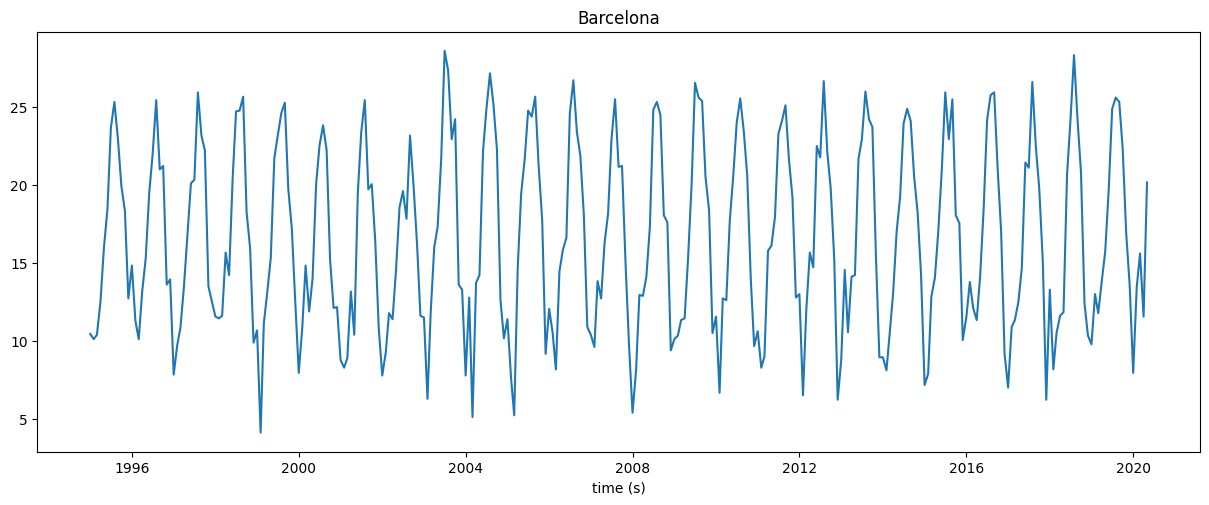

In [69]:
plt.figure(figsize=(15,12))
plt.subplot(2,1,1)
plt.plot(df1.index, df1)
plt.title('Barcelona')
plt.xlabel('time (s)')

In [68]:
df1

date
1995-01-01    10.444444
1995-02-01    10.111111
1995-03-01    10.388889
1995-04-01    12.500000
1995-05-01    15.944444
                ...    
2020-01-01     7.944444
2020-02-01    13.444444
2020-03-01    15.611111
2020-04-01    11.555556
2020-05-01    20.166667
Name: AvgTemperature, Length: 305, dtype: float64

# ARIMA

In [70]:
myarima = ARIMA_model(df1)

In [71]:
myarima.train_test_split_ts()

In [72]:
myarima.order

(1, 1, 1)

In [73]:
myarima.check_stationarity()

ADF Statistic: -3.323879541273932
p-value: 0.013844222549762043
Critical values:
	1%: -3.453
	5%: -2.871
	10%: -2.572


np.True_

In [74]:
myarima.find_optimal_d()

ADF Statistic: -3.323879541273932
p-value: 0.013844222549762043
Critical values:
	1%: -3.453
	5%: -2.871
	10%: -2.572
Optional d: 0


0

In [75]:
myarima.order = (2, 0, 2)
myarima.order

(2, 0, 2)

In [76]:
myarima.fit_model()

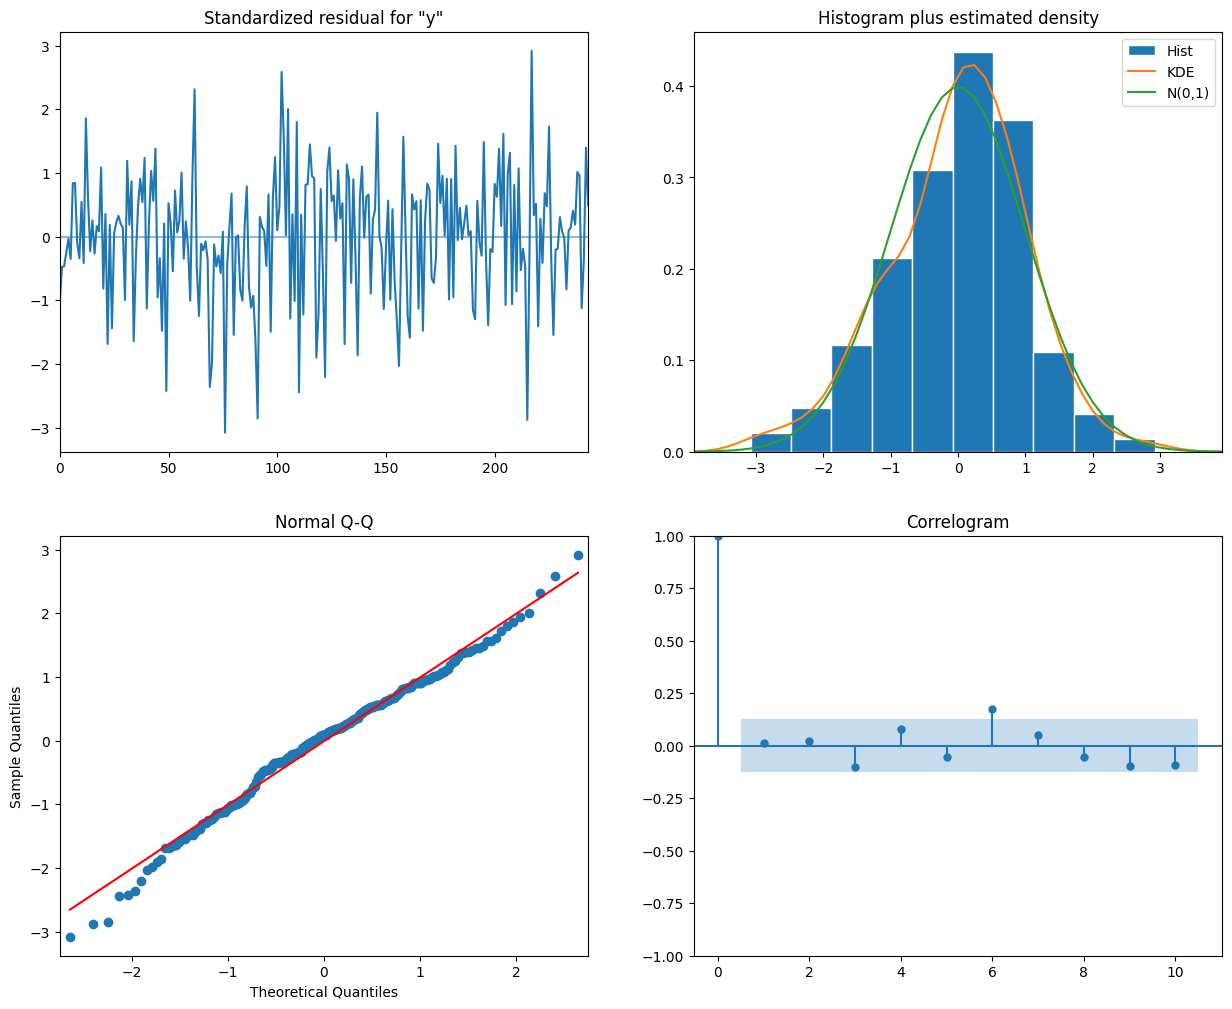

In [77]:
myarima.plot_diagnostics()

In [78]:
myarima.suggest_model_improvements()

Порядок AR соответствует модели
Порядок MA соответствует модели


In [79]:
pred = myarima.predict(10)
pred

array([17.09973184, 21.01851743, 23.74143402, 24.53733633, 23.19263368,
       20.06860981, 16.00435616, 12.0913976 ,  9.3805448 ,  8.59970287])

In [80]:
myarima.evaluate_predictions(myarima.test[:10], pred)

{'MSE': 5.462563214419866,
 'RMSE': np.float64(2.3372127020063593),
 'MAE': 1.9082108857058397,
 'R2': 0.8022570621212961}

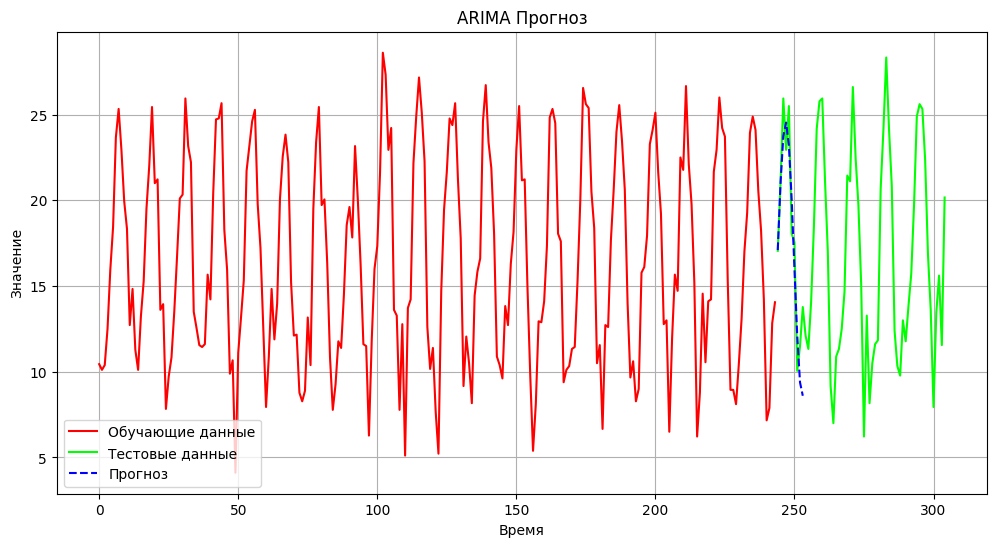

In [81]:
myarima.plot_predictions(pred)

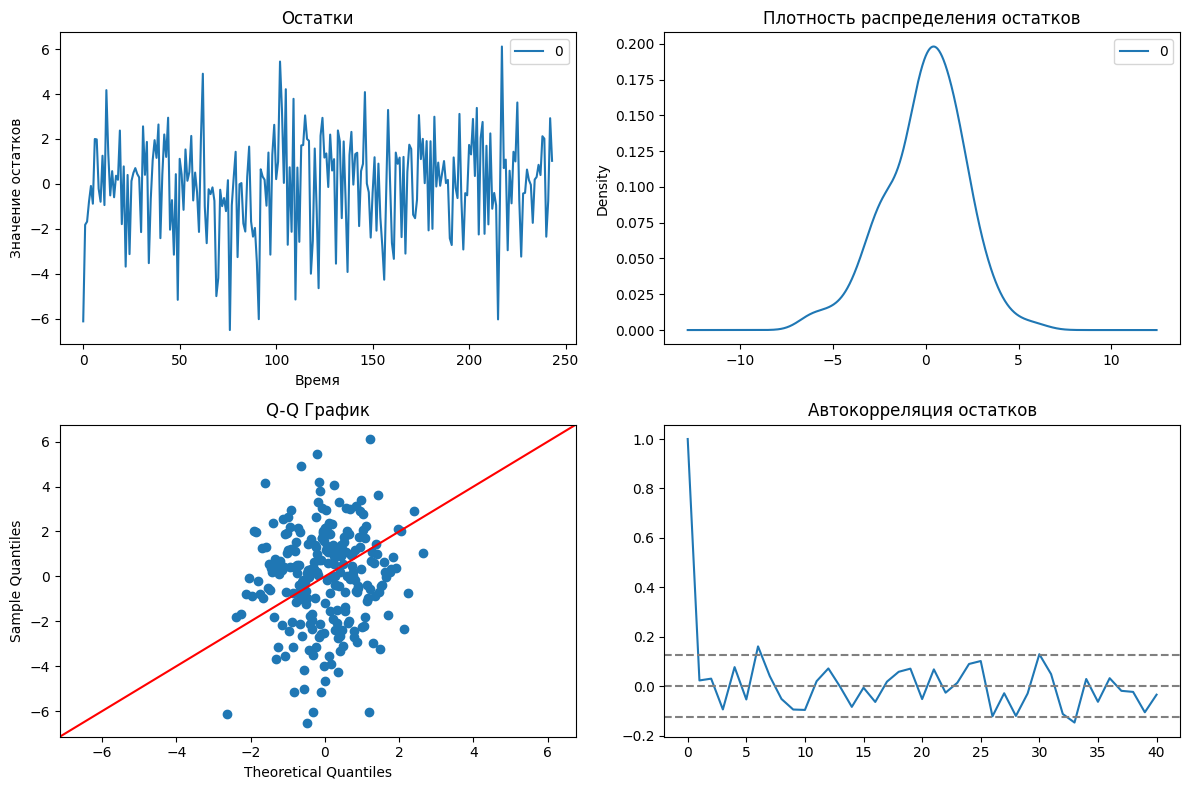

In [82]:
myarima.plot_residuals()

# SARIMA

In [83]:
myarima2 = SARIMA_model(df1)

In [84]:
myarima2.train_test_split_ts()

In [85]:
myarima2.check_stationarity()

ADF Statistic: -3.323879541273932
p-value: 0.013844222549762043
Critical values:
	1%: -3.453
	5%: -2.871
	10%: -2.572


np.True_

In [86]:
myarima2.find_optimal_d()

ADF Statistic: -3.323879541273932
p-value: 0.013844222549762043
Critical values:
	1%: -3.453
	5%: -2.871
	10%: -2.572
Optional d: 0


0

In [87]:
myarima2.find_optimal_D(12)

ADF Statistic: -3.323879541273932
p-value: 0.013844222549762043
Critical values:
	1%: -3.453
	5%: -2.871
	10%: -2.572
Optional D: 0


0

In [93]:
myarima2.order

(1, 0, 1)

In [130]:
myarima2.seasonal_order = (4,0,0,12)
myarima2.seasonal_order

(4, 0, 0, 12)

In [131]:
myarima2.fit_model()

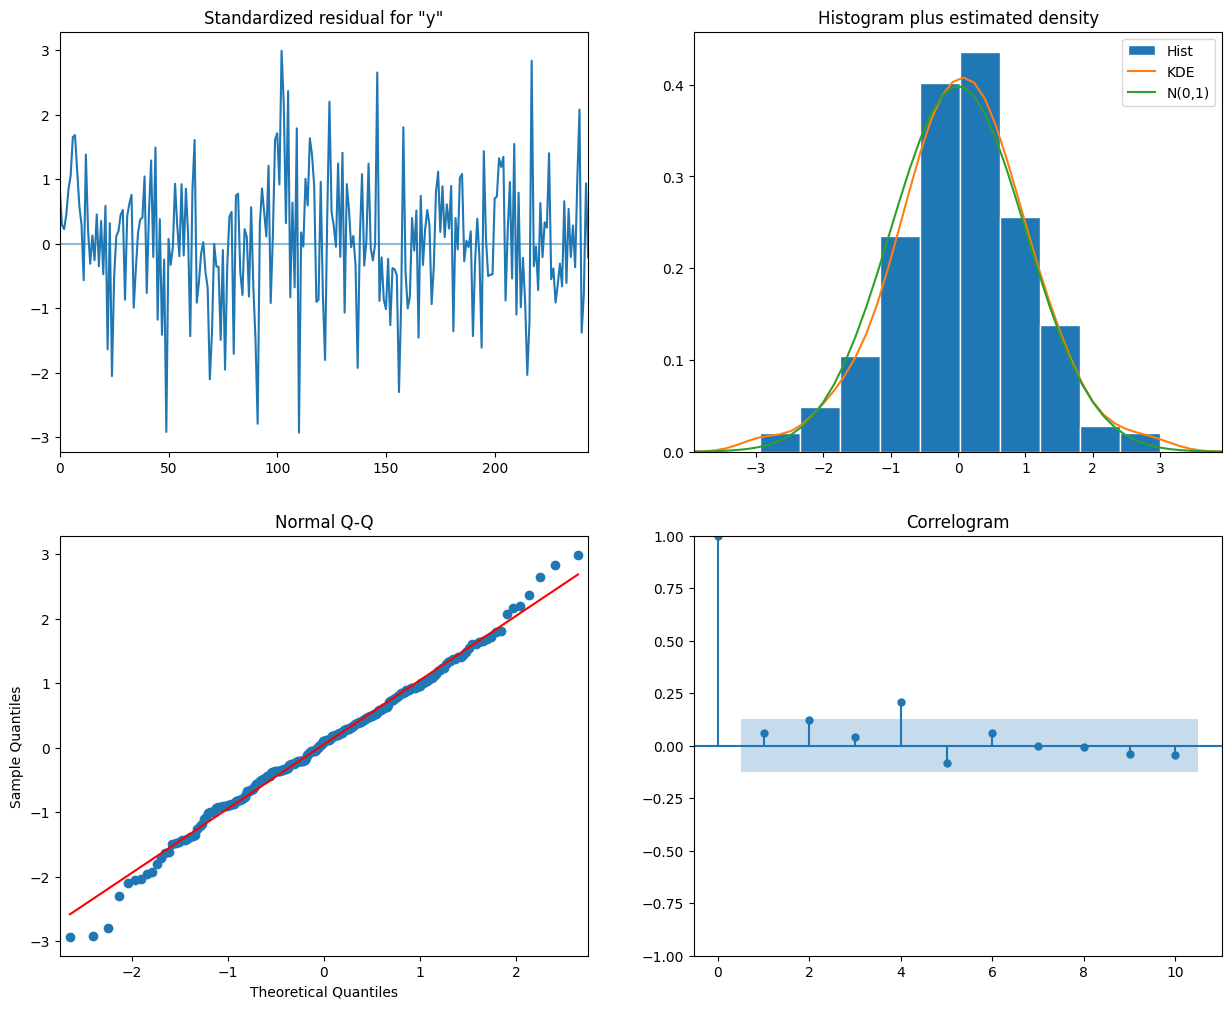

In [132]:
myarima2.plot_diagnostics()

In [133]:
pred2 = myarima2.predict(30)
pred2

array([15.57771958, 20.25206346, 22.84634255, 25.15616071, 23.66052673,
       21.29492043, 16.9605793 , 10.86507274,  9.39318013,  9.3817074 ,
       11.63401916, 14.19887852, 15.49683476, 20.62727229, 22.7429268 ,
       25.29938117, 23.37171716, 21.18278975, 16.57513693, 10.55794726,
        8.79188575,  9.92762774, 11.60307843, 13.9595835 , 15.61328562,
       20.30072524, 22.87380182, 25.03412883, 23.55777125, 21.41905832])

In [129]:
myarima2.evaluate_predictions(myarima2.test[:30], pred2)

{'MSE': 4.584928378580816,
 'RMSE': np.float64(2.1412445863517826),
 'MAE': 1.8214760796830756,
 'R2': 0.8617581089262683}

In [134]:
myarima2.evaluate_predictions(myarima2.test[:30], pred2)

{'MSE': 3.3368543612684416,
 'RMSE': np.float64(1.8267058770553188),
 'MAE': 1.5506112248705193,
 'R2': 0.8993892556109756}

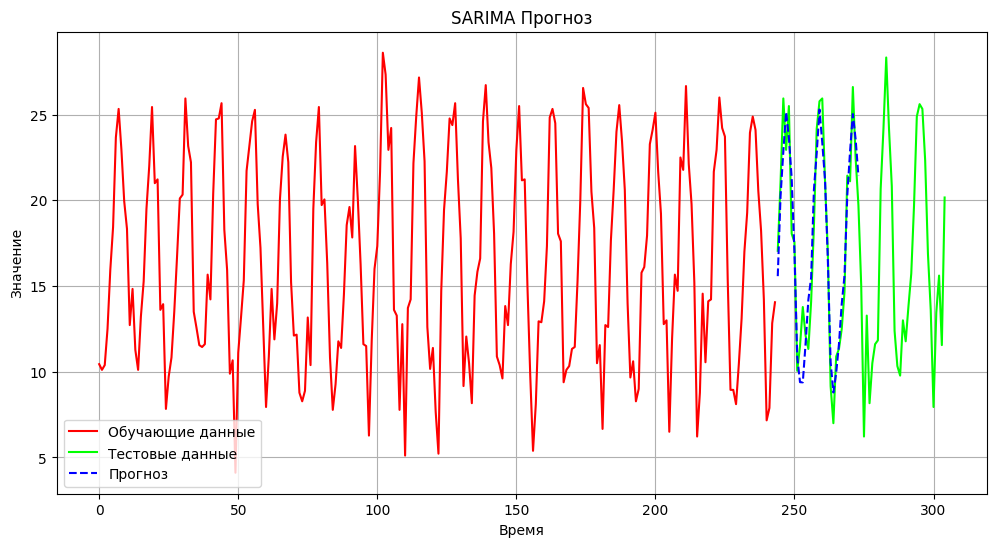

In [135]:
myarima2.plot_predictions(pred2)

# ARCH

In [35]:
myarima3 = ARCH_model(df1)

In [36]:
myarima3.fit_arch_model()

In [38]:
myarima3.cross_validate_model(myarima3.data)

c:\Users\George\VS Code Projects\VmdVme 2\Prediction\optional.py:398: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  train_returns = returns[train_index]
c:\Users\George\VS Code Projects\VmdVme 2\Prediction\optional.py:399: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_returns = returns[test_index]
c:\Users\George\VS Code Projects\VmdVme 2\Prediction\optional.py:398: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  train_returns = 

Iteration:      1,   Func. Count:      5,   Neg. LLF: 3639934710522.2656
Iteration:      2,   Func. Count:     11,   Neg. LLF: 7530280943.246414
Iteration:      3,   Func. Count:     16,   Neg. LLF: 45882.13698855328
Iteration:      4,   Func. Count:     22,   Neg. LLF: 1941828.5372069108
Iteration:      5,   Func. Count:     27,   Neg. LLF: 981683.0312537043
Iteration:      6,   Func. Count:     33,   Neg. LLF: 27057.720227304846
Iteration:      7,   Func. Count:     37,   Neg. LLF: 27056.419735814517
Iteration:      8,   Func. Count:     41,   Neg. LLF: 27055.903379967556
Iteration:      9,   Func. Count:     45,   Neg. LLF: 27055.890889950657
Iteration:     10,   Func. Count:     49,   Neg. LLF: 27055.889238300224
Iteration:     11,   Func. Count:     52,   Neg. LLF: 27055.889238300042
Optimization terminated successfully    (Exit mode 0)
            Current function value: 27055.889238300224
            Iterations: 11
            Function evaluations: 52
            Gradient evalua

c:\Users\George\VS Code Projects\VmdVme 2\Prediction\optional.py:398: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  train_returns = returns[train_index]
c:\Users\George\VS Code Projects\VmdVme 2\Prediction\optional.py:399: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_returns = returns[test_index]
c:\Users\George\VS Code Projects\VmdVme 2\Prediction\optional.py:398: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  train_returns = 

(np.float64(12.635003271027873), np.float64(0.5702589334152477))

In [40]:
myarima3.predict(100)

Iteration:      1,   Func. Count:      5,   Neg. LLF: 3639934710522.2656
Iteration:      2,   Func. Count:     11,   Neg. LLF: 7530280943.246414
Iteration:      3,   Func. Count:     16,   Neg. LLF: 45882.13698855328
Iteration:      4,   Func. Count:     22,   Neg. LLF: 1941828.5372069108
Iteration:      5,   Func. Count:     27,   Neg. LLF: 981683.0312537043
Iteration:      6,   Func. Count:     33,   Neg. LLF: 27057.720227304846
Iteration:      7,   Func. Count:     37,   Neg. LLF: 27056.419735814517
Iteration:      8,   Func. Count:     41,   Neg. LLF: 27055.903379967556
Iteration:      9,   Func. Count:     45,   Neg. LLF: 27055.890889950657
Iteration:     10,   Func. Count:     49,   Neg. LLF: 27055.889238300224
Iteration:     11,   Func. Count:     52,   Neg. LLF: 27055.889238300042
Optimization terminated successfully    (Exit mode 0)
            Current function value: 27055.889238300224
            Iterations: 11
            Function evaluations: 52
            Gradient evalua

array([2.82015607, 3.11036672, 3.35584432, 3.56729737, 3.75176373,
       3.91419203, 4.05823525, 4.18669056, 4.30176152, 4.40522375,
       4.4985345 , 4.58290792, 4.65936838, 4.72878939, 4.79192252,
       4.84941945, 4.90184903, 4.94971071, 4.99344521, 5.03344315,
       5.07005212, 5.1035825 , 5.13431228, 5.16249111, 5.18834379,
       5.21207312, 5.23386247, 5.25387791, 5.27227009, 5.28917584,
       5.30471966, 5.3190149 , 5.33216492, 5.34426403, 5.35539839,
       5.36564672, 5.37508107, 5.38376738, 5.39176606, 5.39913244,
       5.4059173 , 5.41216719, 5.41792485, 5.42322952, 5.42811723,
       5.4326211 , 5.43677154, 5.44059654, 5.44412182, 5.44737104,
       5.45036596, 5.45312661, 5.45567142, 5.45801736, 5.46018004,
       5.46217384, 5.46401201, 5.46570674, 5.46726927, 5.46870993,
       5.47003827, 5.47126306, 5.4723924 , 5.47343374, 5.47439396,
       5.47527938, 5.47609585, 5.47684874, 5.47754302, 5.47818324,
       5.47877363, 5.47931807, 5.47982014, 5.48028314, 5.48071

In [41]:
myarima3.historical_volatility()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 3639934710522.2656
Iteration:      2,   Func. Count:     11,   Neg. LLF: 7530280943.246414
Iteration:      3,   Func. Count:     16,   Neg. LLF: 45882.13698855328
Iteration:      4,   Func. Count:     22,   Neg. LLF: 1941828.5372069108
Iteration:      5,   Func. Count:     27,   Neg. LLF: 981683.0312537043
Iteration:      6,   Func. Count:     33,   Neg. LLF: 27057.720227304846
Iteration:      7,   Func. Count:     37,   Neg. LLF: 27056.419735814517
Iteration:      8,   Func. Count:     41,   Neg. LLF: 27055.903379967556
Iteration:      9,   Func. Count:     45,   Neg. LLF: 27055.890889950657
Iteration:     10,   Func. Count:     49,   Neg. LLF: 27055.889238300224
Iteration:     11,   Func. Count:     52,   Neg. LLF: 27055.889238300042
Optimization terminated successfully    (Exit mode 0)
            Current function value: 27055.889238300224
            Iterations: 11
            Function evaluations: 52
            Gradient evalua

date
1995-01-01    2.799037
1995-01-02    1.903817
1995-01-03    2.611686
1995-01-04    2.941230
1995-01-05    3.097991
                ...   
2020-05-09    2.424799
2020-05-10    2.215387
2020-05-11    2.026188
2020-05-12    2.203922
2020-05-13    1.939441
Name: cond_vol, Length: 9236, dtype: float64